In [47]:
import sys
import os
sys.path.append(os.path.abspath('..'))


import pandas as pd
import numpy as np

from data_preparation.data_processor import DataProcessor
#from models import XGBoostParams

import xgboost as xgb
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL


In [48]:
XGBoostParams =  {
    "Municipal": {
        "colsample_bytree": 0.8,
        "gamma": 0,
        "learning_rate": 0.03,
        "max_depth": 4,
        "min_child_weight": 3,
        "n_estimators": 90,
        "reg_alpha": 0,
        "reg_lambda": 1
    },
    "Industrial": {
        "colsample_bytree": 0.8,
        "gamma": 0,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 5,
        "n_estimators": 70,
        "reg_alpha": 0,
        "reg_lambda": 0.5
    },
    "Organic": {
        "colsample_bytree": 0.8,
        "gamma": 0,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 5,
        "n_estimators": 110,
        "reg_alpha": 0.5,
        "reg_lambda": 1
    },
    "Construction": {
        "colsample_bytree": 0.8,
        "gamma": 0,
        "learning_rate": 0.09000000000000001,
        "max_depth": 3,
        "min_child_weight": 5,
        "n_estimators": 70,
        "reg_alpha": 0,
        "reg_lambda": 1
    },
    "Commercial": {
        "colsample_bytree": 1.0,
        "gamma": 0,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 3,
        "n_estimators": 70,
        "reg_alpha": 0.5,
        "reg_lambda": 1
    }
}

In [49]:
waste_data = pd.read_csv("../synthetic_waste_data.csv")

fetcher = DataProcessor(waste_data)

unique_waste = fetcher.waste_data['waste_type'].unique()
diff_waste_dfs = {}

lags = [1,6]

for waste in unique_waste:
    prep_data_company = fetcher.agg_quantity(waste_type=waste, by_waste_type= True)
    prep_data_company["quantity_tons"] = prep_data_company["quantity_tons"].diff() 

    diff_waste_dfs[waste] = fetcher.create_xgboost_features(prep_data_company, lags=lags, lagged_features= True,lagged_ratios= False ,fourier_terms= False, interaction_terms= False)


for c in range(len(unique_waste)):
    waste = list(diff_waste_dfs.keys())[c]
    print(f"Data shape for {waste}:")
    print(diff_waste_dfs[waste].shape)

Data shape for Municipal:
(1089, 16)
Data shape for Industrial:
(1089, 16)
Data shape for Organic:
(1089, 16)
Data shape for Construction:
(1089, 16)
Data shape for Commercial:
(1089, 16)


In [50]:
diff_waste_dfs["Municipal"]

,is_Fall,is_Spring,is_Summer,is_Winter,quantity_tons,is_weekend,is_holiday,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag_1,lag_6
date,,,,,,,,,,,,,,,,
2022-01-08,0.0,0.0,0.0,1.0,-28.714958,1.0,0.0,5,1,1,2022,8,8,1,-9.711624,-16.381126
2022-01-09,0.0,0.0,0.0,1.0,-57.887192,1.0,0.0,6,1,1,2022,9,9,1,-28.714958,230.263626
2022-01-10,0.0,0.0,0.0,1.0,87.551895,0.0,0.0,0,1,1,2022,10,10,2,-57.887192,-106.199791
2022-01-11,0.0,0.0,0.0,1.0,-4.451279,0.0,0.0,1,1,1,2022,11,11,2,87.551895,-49.582886
2022-01-12,0.0,0.0,0.0,1.0,-3.140831,0.0,0.0,2,1,1,2022,12,12,2,-4.451279,21.832825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,0.0,0.0,0.0,1.0,-97.968933,0.0,1.0,4,4,12,2024,362,27,52,236.426361,-43.349083
2024-12-28,0.0,0.0,0.0,1.0,-140.899521,1.0,1.0,5,4,12,2024,363,28,52,-97.968933,-13.684878
2024-12-29,0.0,0.0,0.0,1.0,-84.930397,1.0,0.0,6,4,12,2024,364,29,52,-140.899521,277.887909


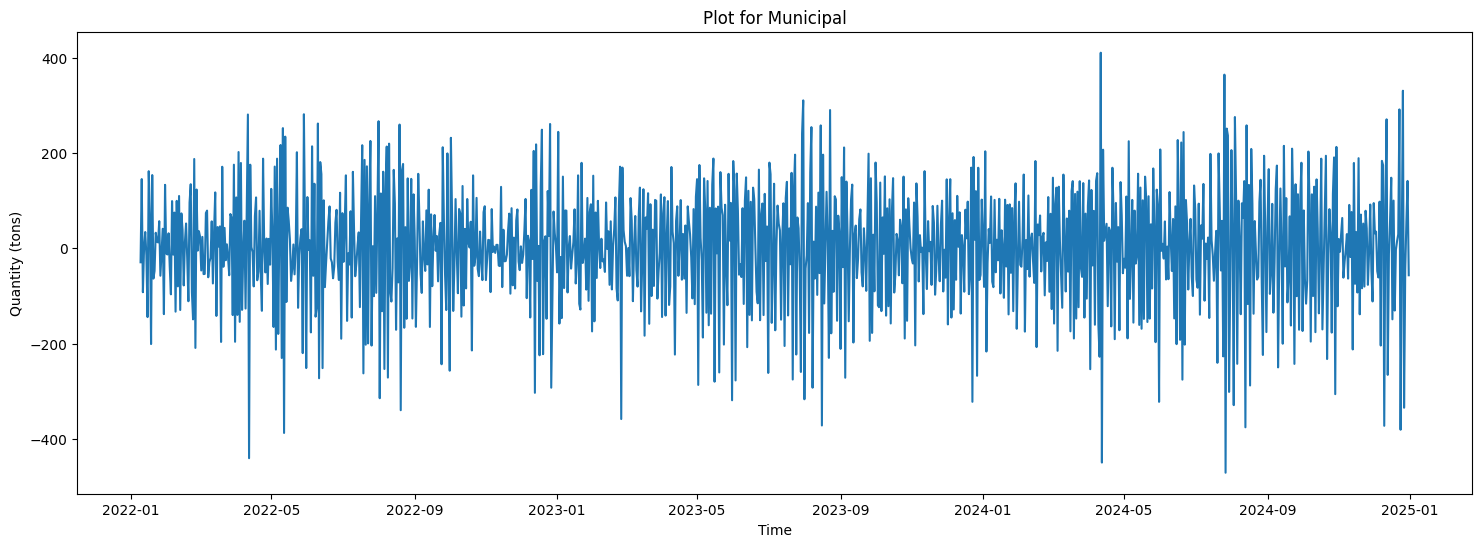

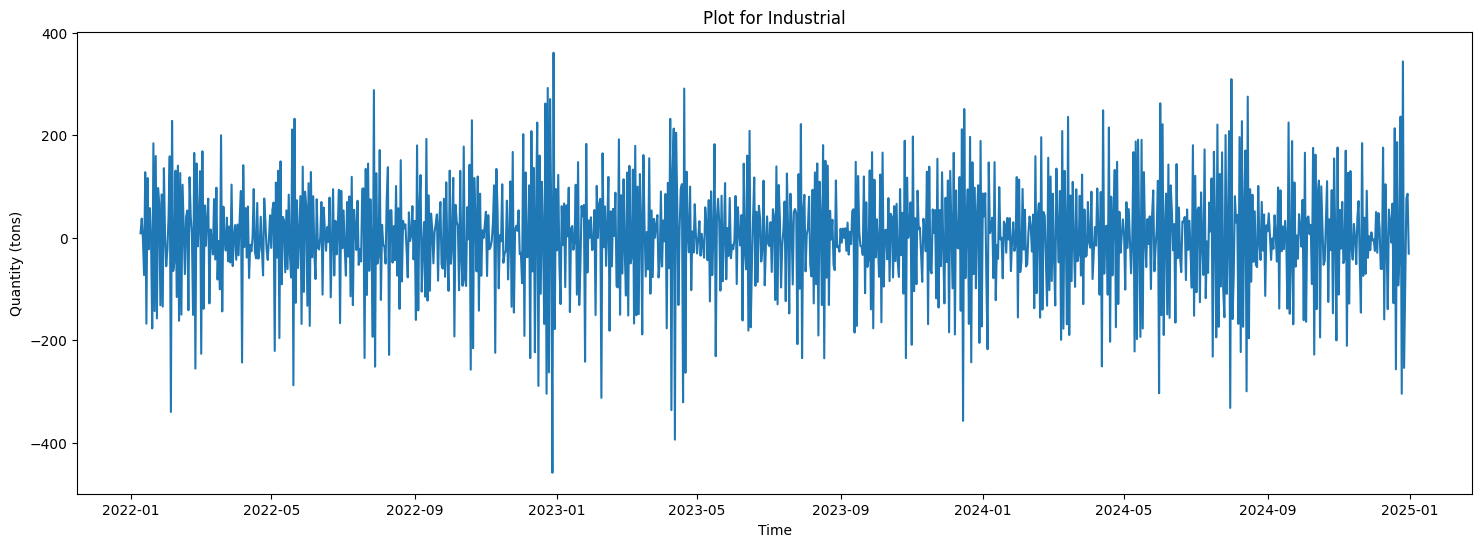

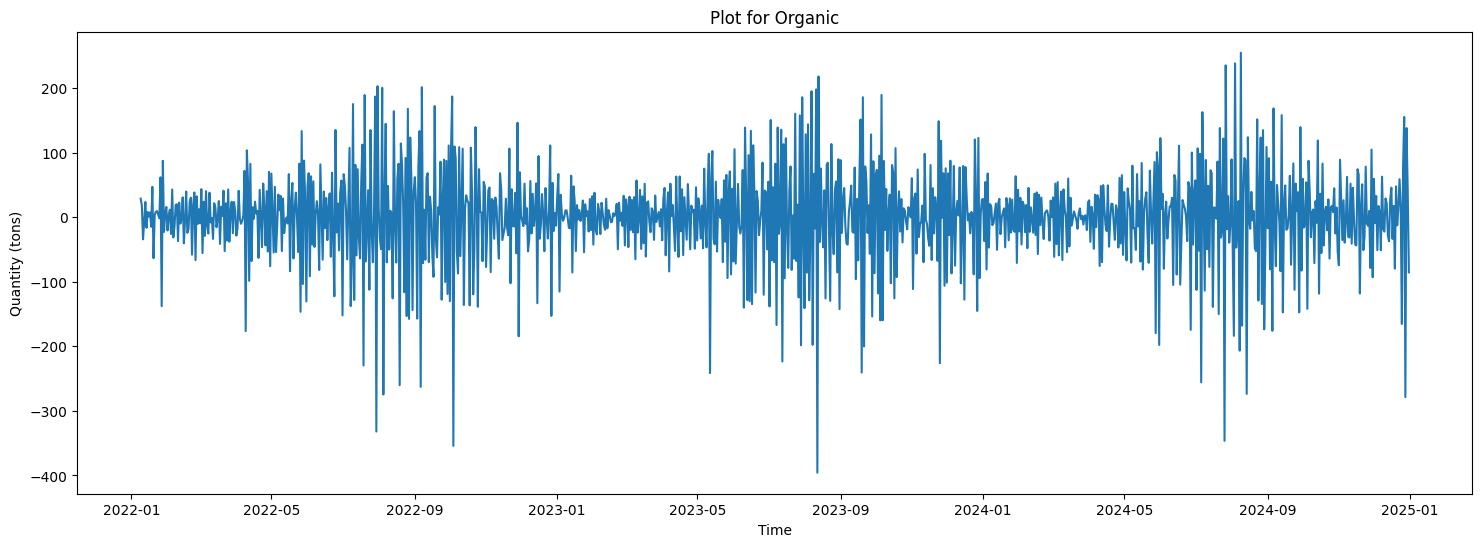

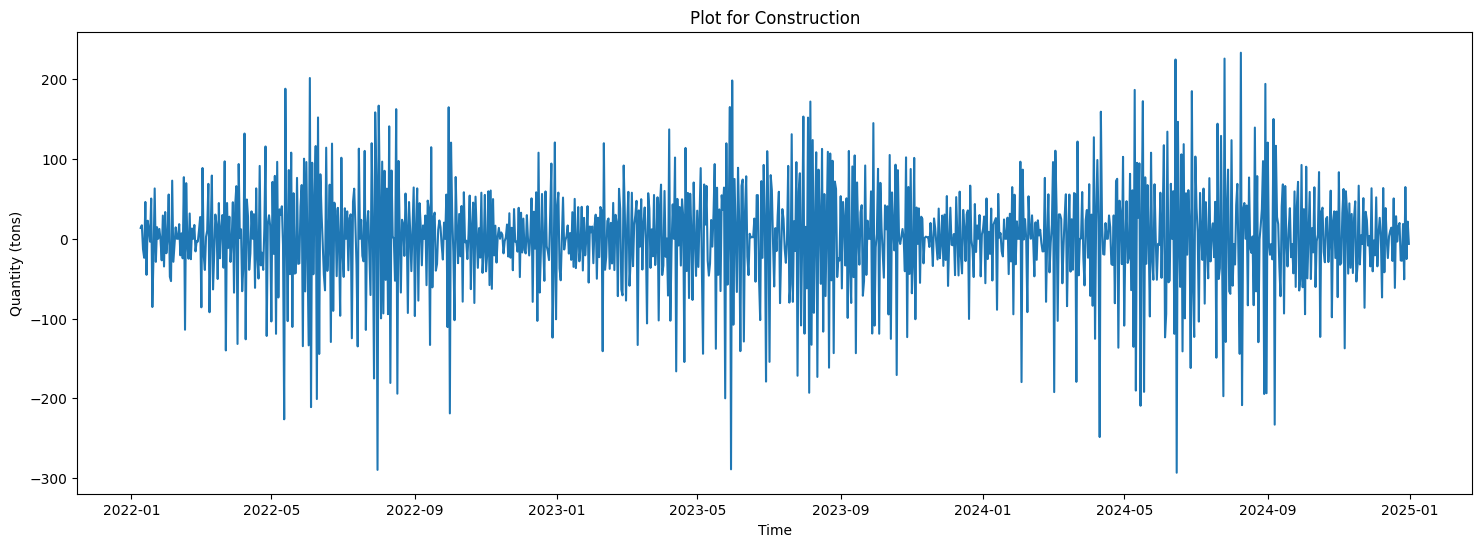

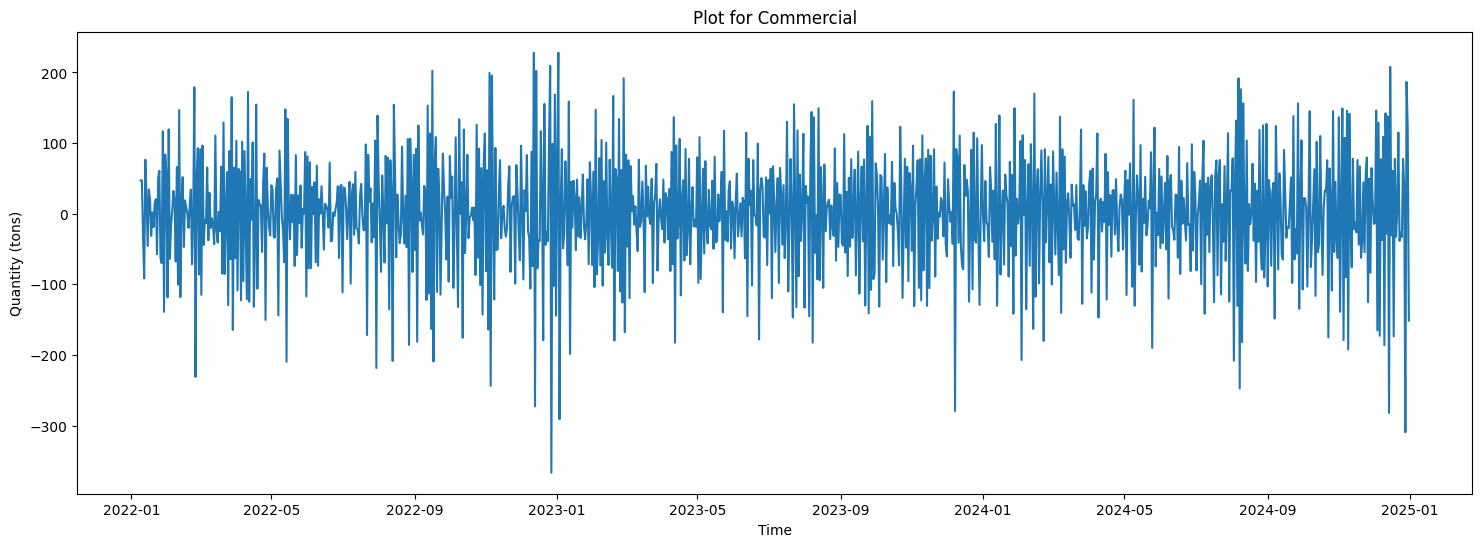

In [51]:
for waste in unique_waste:
    plt.figure(figsize=(18,6))
    # Filter out zero values
    #non_zero_data = waste_dfs[waste][waste_dfs[waste]["quantity_tons"] > 0]
    #differenced_data = non_zero_data.diff()
    differenced_data = diff_waste_dfs[waste].diff()
    plt.plot(differenced_data["quantity_tons"])
    plt.title(f"Plot for {waste}")
    plt.xlabel("Time")
    plt.ylabel("Quantity (tons)")
    plt.show()


In [ ]:
from statsmodels.tsa.stattools import adfuller

# Dictionary to store results
stationarity_results = {}

for waste in unique_waste:
    ts = diff_waste_dfs[waste]["quantity_tons"].dropna()  # Ensure no NaN values
    
    # Perform ADF test
    result = adfuller(ts, autolag = "AIC")
    
    # Store results
    stationarity_results[waste] = {
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Critical Values": result[4],
        "Stationary": result[1] < 0.05  # True if p-value is below 0.05
    }
    
    print(f"Waste Type: {waste}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values: {result[4]}")
    print("-" * 40)

Waste Type: Municipal
ADF Statistic: -5.6224
p-value: 0.0000
Critical Values: {'1%': -3.43674585579594, '5%': -2.8643638720413227, '10%': -2.5682735516954196}
----------------------------------------
Waste Type: Industrial
ADF Statistic: -6.7144
p-value: 0.0000
Critical Values: {'1%': -3.4366961996098264, '5%': -2.8643419712141074, '10%': -2.5682618869934934}
----------------------------------------
Waste Type: Organic
ADF Statistic: -10.2916
p-value: 0.0000
Critical Values: {'1%': -3.4365224825380714, '5%': -2.86426535058257, '10%': -2.568221078163292}
----------------------------------------
Waste Type: Construction
ADF Statistic: -5.0633
p-value: 0.0000
Critical Values: {'1%': -3.4367396063176874, '5%': -2.8643611157329905, '10%': -2.5682720836420705}
----------------------------------------
Waste Type: Commercial
ADF Statistic: -6.0126
p-value: 0.0000
Critical Values: {'1%': -3.436777287462024, '5%': -2.8643777347701866, '10%': -2.5682809352172242}
---------------------------------

<Figure size 1000x800 with 0 Axes>

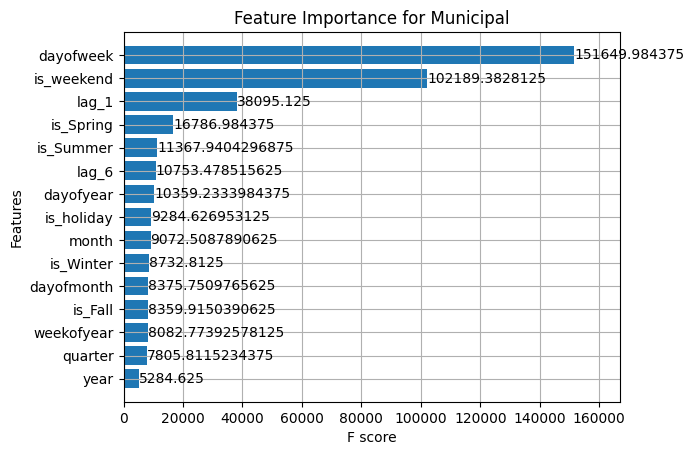

<Figure size 1000x800 with 0 Axes>

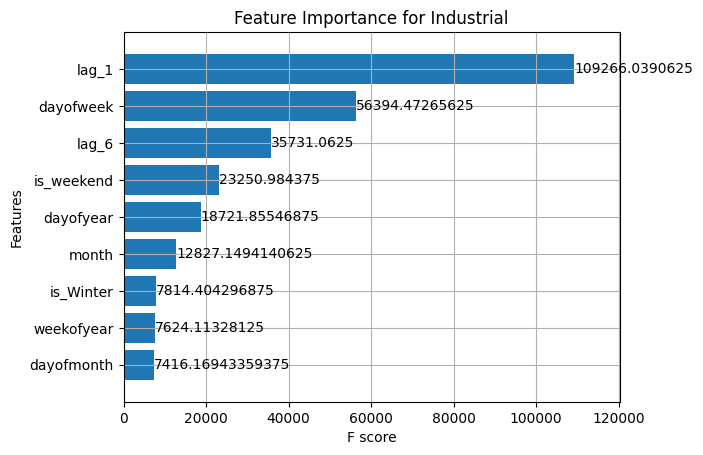

<Figure size 1000x800 with 0 Axes>

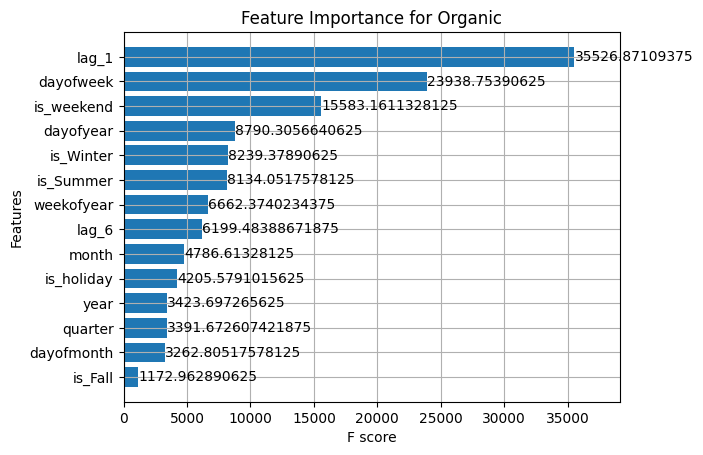

<Figure size 1000x800 with 0 Axes>

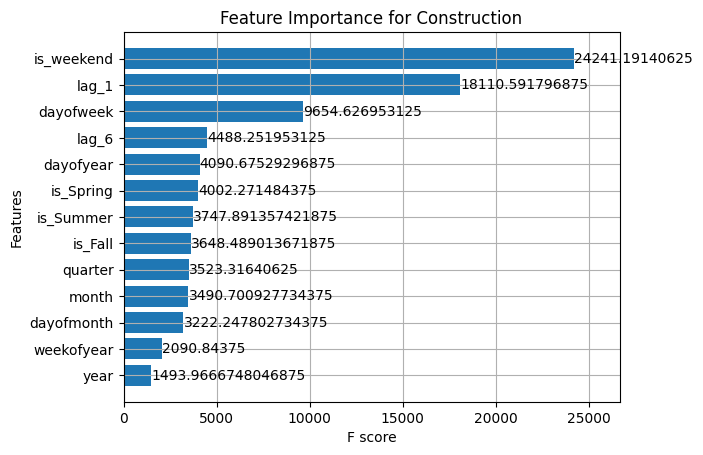

<Figure size 1000x800 with 0 Axes>

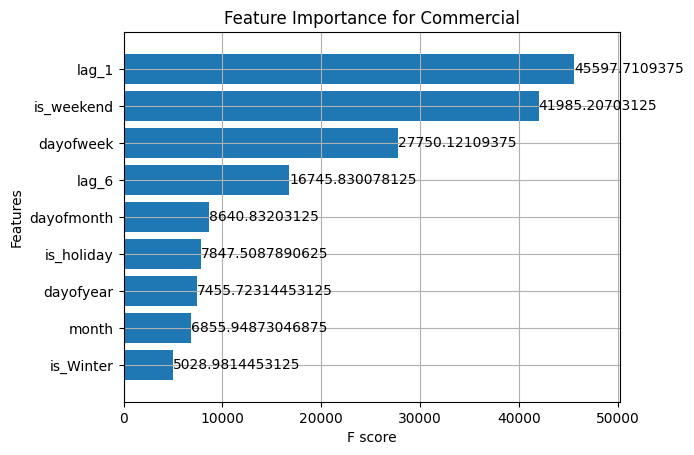

In [53]:
split_index = int(diff_waste_dfs["Municipal"].shape[0] * 0.8)


waste_quantity_preds = {}

for waste, df in diff_waste_dfs.items():

    X = df.drop(columns=['quantity_tons'])
    y = df['quantity_tons']

    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]
    
    # Get the best parameters for this company
    best_params = XGBoostParams[waste]
    
    # Create and train the model with best parameters
    best_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        **best_params  # Unpack the parameters
    )
    
    best_model.fit(X_train, y_train)

    y_pred = best_model.predict(X_test)
    waste_quantity_preds[waste] = y_pred

    # Plot feature importance
    plt.figure(figsize=(10, 8))
    xgb.plot_importance(best_model, max_num_features=20, height=0.8, importance_type="gain")
    plt.title(f"Feature Importance for {waste}")
    plt.show()

In [54]:
from sklearn.metrics import root_mean_squared_error

total_actual = np.sum(
    [diff_waste_dfs[waste]['quantity_tons'].values[split_index:] for waste in diff_waste_dfs],
    axis=0
)


total_predicted = np.sum(list(waste_quantity_preds.values()), axis=0)

print(f"RMSE:{root_mean_squared_error(total_actual, total_predicted)}")

for waste in unique_waste:
    actual = np.sum(
    [diff_waste_dfs[waste]['quantity_tons'].values[split_index:]],
    axis=0)

    predicted = waste_quantity_preds[waste]

    print(f"RMSE for {waste}: {root_mean_squared_error(actual, predicted)}")


RMSE:117.56205749511719
RMSE for Municipal: 64.62898254394531
RMSE for Industrial: 51.74484634399414
RMSE for Organic: 43.57914352416992
RMSE for Construction: 36.38328170776367
RMSE for Commercial: 42.94778823852539


In [55]:
original_waste_dfs = {}


for waste in unique_waste:
    prep_data_company = fetcher.agg_quantity(waste_type=waste, by_waste_type= True)
    prep_data_company["quantity_tons"] = prep_data_company["quantity_tons"].shift(-1).fillna(0)

    original_waste_dfs[waste] = fetcher.create_xgboost_features(prep_data_company, lags=lags, lagged_features= True,lagged_ratios= False ,fourier_terms= False, interaction_terms= False)


for c in range(len(unique_waste)):
    waste = list(original_waste_dfs.keys())[c]
    print(f"Data shape for {waste}:")
    print(original_waste_dfs[waste].shape)

Data shape for Municipal:
(1090, 16)
Data shape for Industrial:
(1090, 16)
Data shape for Organic:
(1090, 16)
Data shape for Construction:
(1090, 16)
Data shape for Commercial:
(1090, 16)


In [56]:
total_actual = np.sum(
    [original_waste_dfs[waste]['quantity_tons'].values[split_index+1:] for waste in original_waste_dfs],
    axis=0
)

total_predicted = np.sum(list(waste_quantity_preds.values()), axis=0)

# Convert the predicted differenced values back to the original unit
total_predicted_original = total_predicted + total_actual

# Calculate RMSE on the original unit
rmse = root_mean_squared_error(total_actual, total_predicted_original)
print(f"RMSE: {rmse}")

for waste in unique_waste:
    actual = np.sum(
        [original_waste_dfs[waste]['quantity_tons'].values[split_index+1:]],
        axis=0
    )

    predicted = waste_quantity_preds[waste]

    # Convert the predicted differenced values back to the original unit
    predicted_original = predicted + actual

    # Calculate RMSE on the original unit
    rmse = root_mean_squared_error(actual, predicted_original)
    print(f"RMSE for {waste}: {rmse}")

RMSE: 108.5082015991211
RMSE for Municipal: 52.85135269165039
RMSE for Industrial: 37.27617263793945
RMSE for Organic: 31.174427032470703
RMSE for Construction: 27.75971221923828
RMSE for Commercial: 26.426103591918945


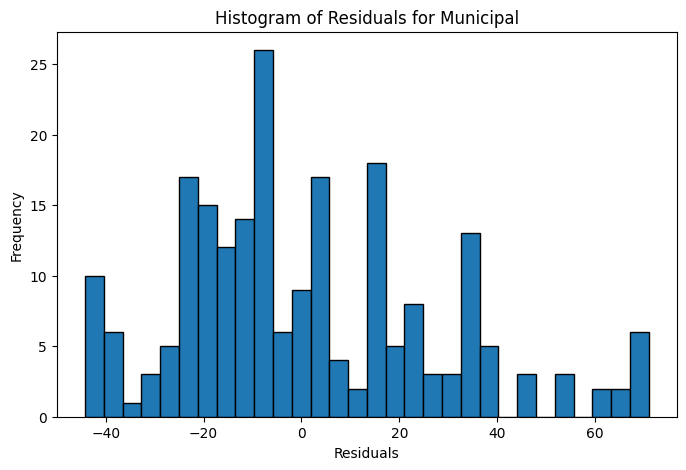

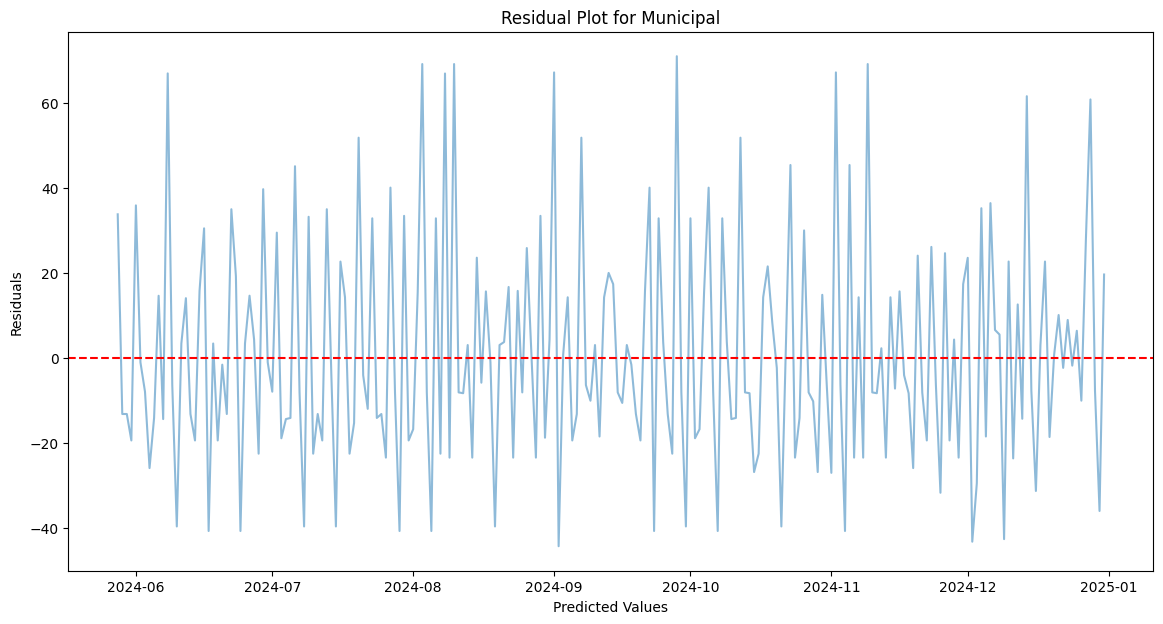

Municipal - Mean Residual: 1.21
Municipal - Standard Deviation: 26.40


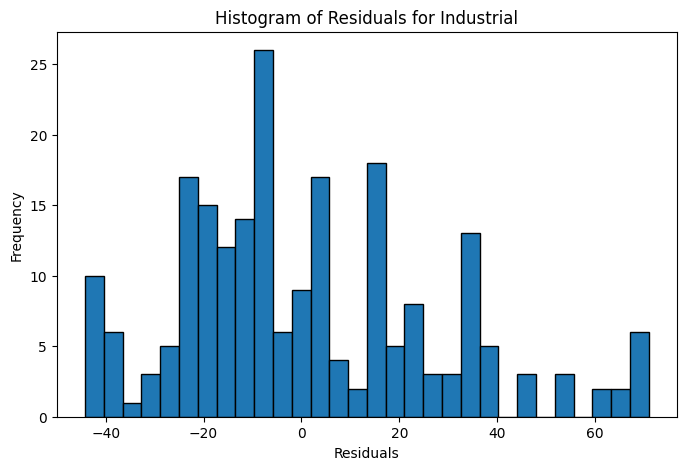

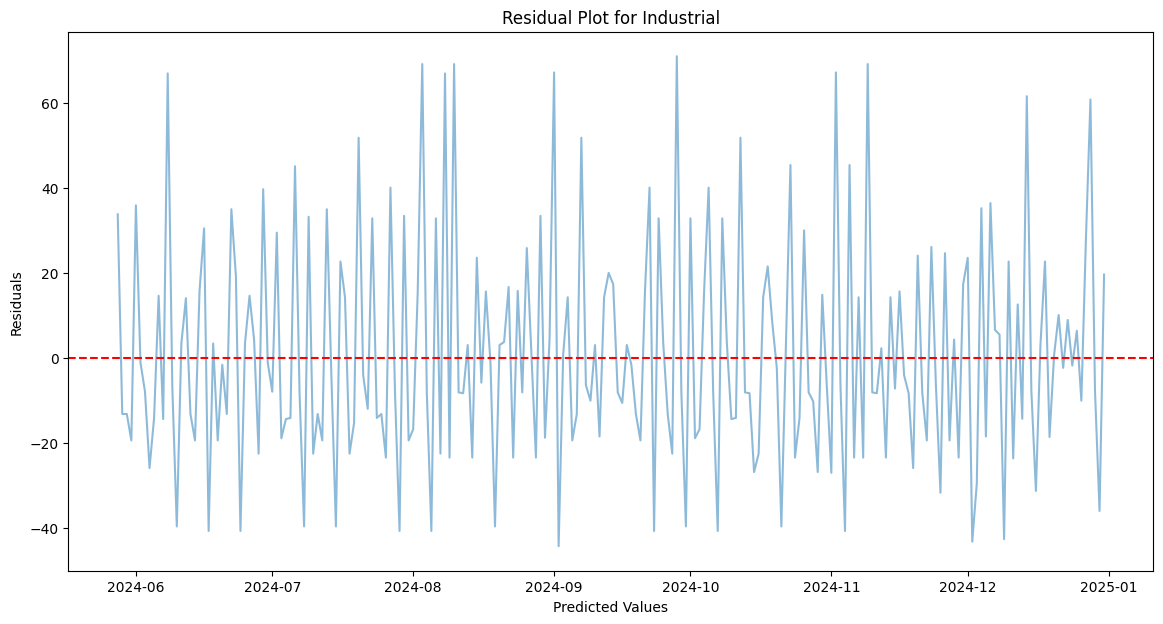

Industrial - Mean Residual: 1.21
Industrial - Standard Deviation: 26.40


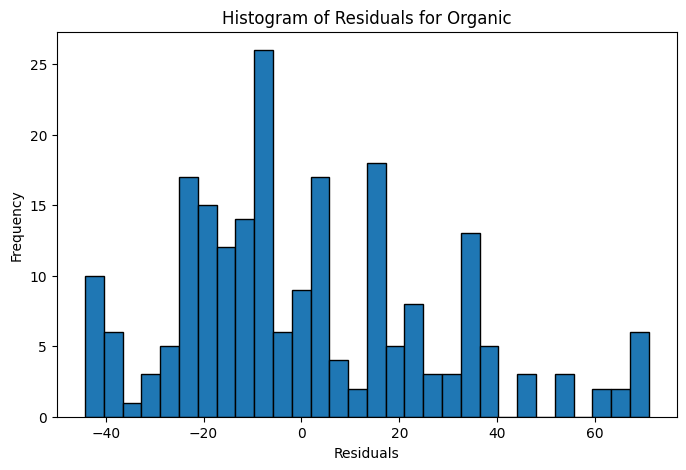

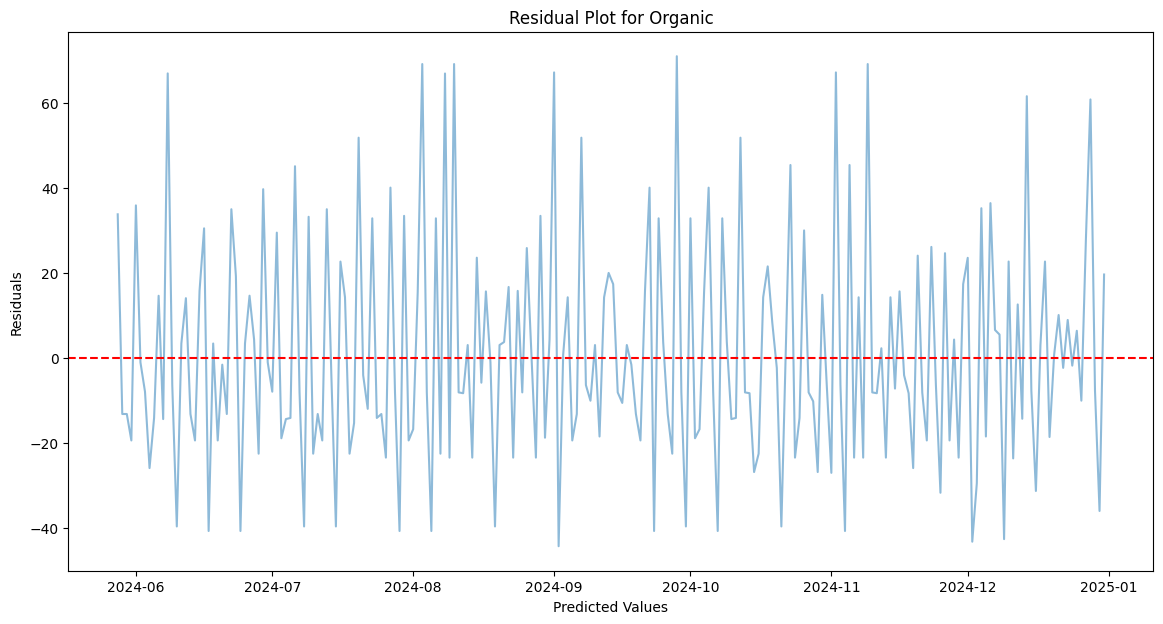

Organic - Mean Residual: 1.21
Organic - Standard Deviation: 26.40


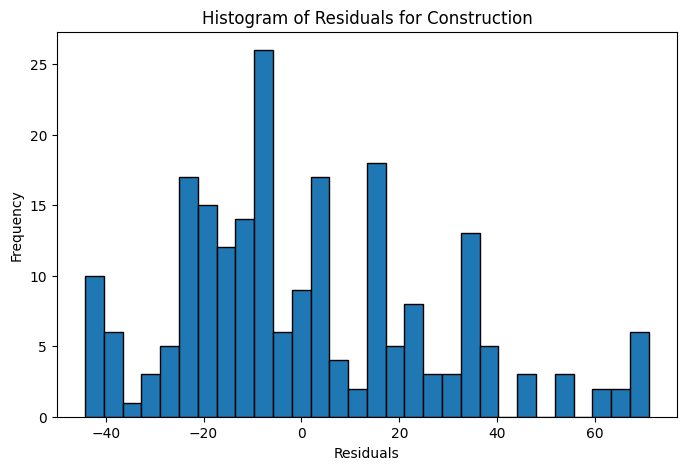

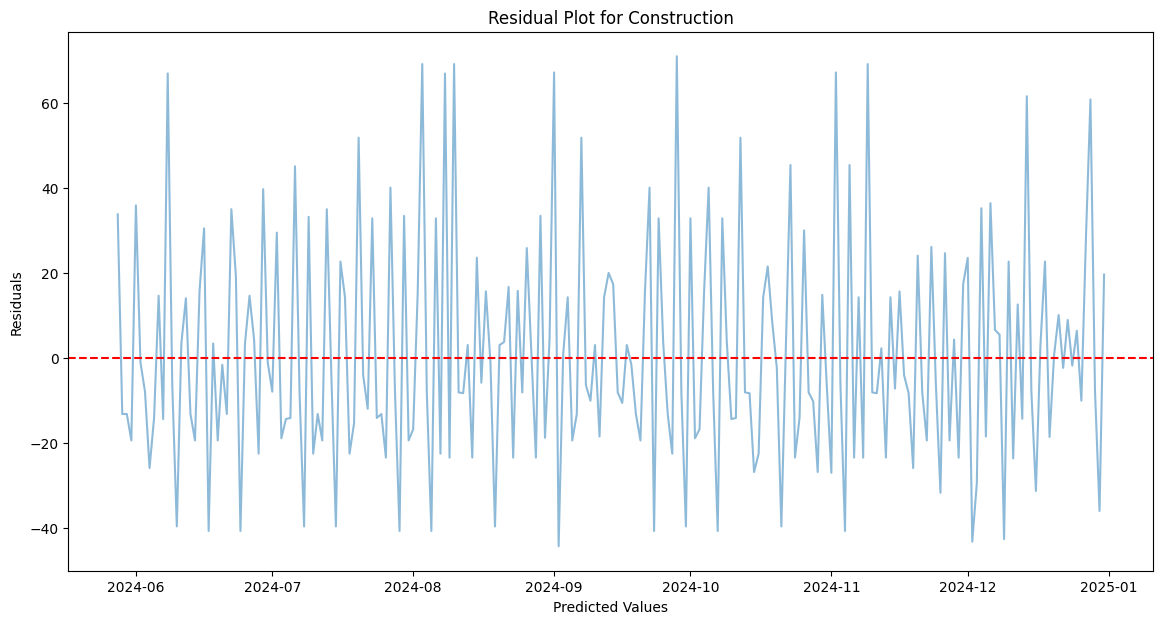

Construction - Mean Residual: 1.21
Construction - Standard Deviation: 26.40


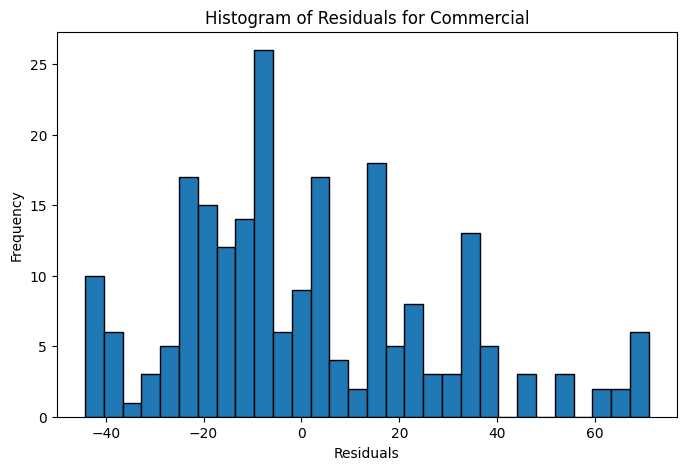

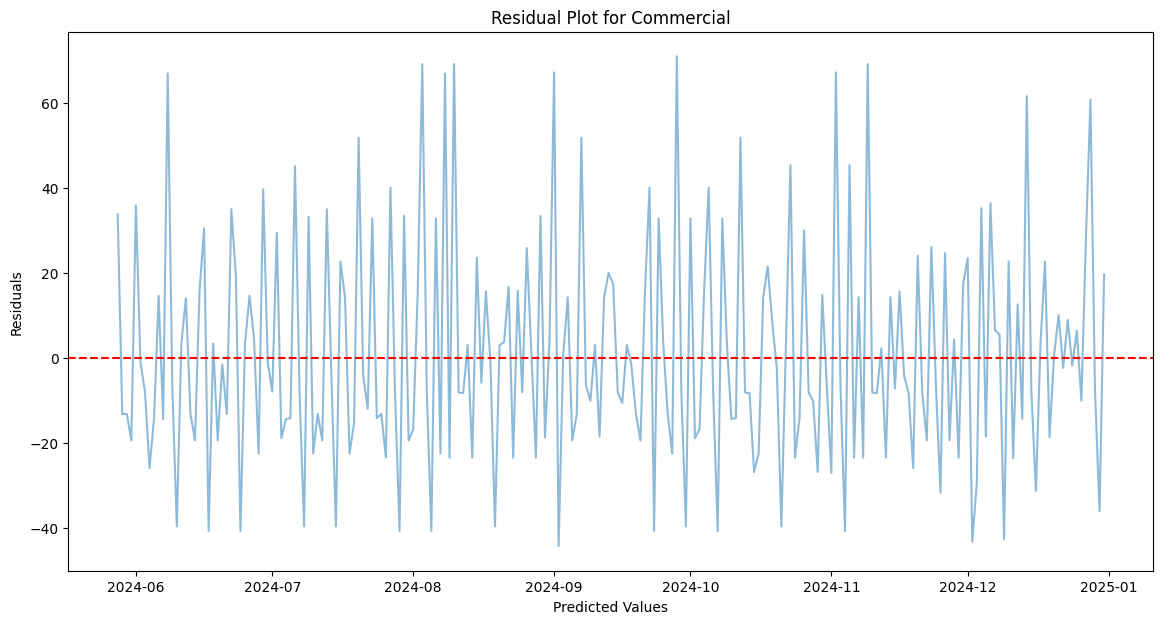

Commercial - Mean Residual: 1.21
Commercial - Standard Deviation: 26.40


In [57]:
# Assuming company_dfs is a dictionary with company names as keys
for waste in original_waste_dfs:
    # Calculate total actual values for the company
    actual = original_waste_dfs[waste]['quantity_tons'].values[split_index+1:]

    # Calculate total predicted values for the company
    total_predicted = waste_quantity_preds[waste]  # Assuming company_quantity_preds is a dict
    predicted_original = predicted + actual

    # Calculate residuals
    residuals = actual - predicted_original
    time_index = original_waste_dfs[waste].index[split_index+1:]

    # Plot histogram of residuals
    plt.figure(figsize=(8, 5))
    plt.hist(residuals, bins=30, edgecolor="black")
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Residuals for {waste}")
    plt.show()

    # Plot residuals against predicted values
    plt.figure(figsize=(14, 7))
    plt.plot(time_index, residuals, alpha=0.5)
    plt.axhline(y=0, color="red", linestyle="--")  # Zero-line for reference
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot for {waste}")
    plt.show()

    # Print mean and standard deviation of residuals
    print(f"{waste} - Mean Residual: {residuals.mean():.2f}")
    print(f"{waste} - Standard Deviation: {residuals.std():.2f}")
